In [ ]:
!pip install -q transformers[torch] datasets accelerate

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset

# 1. Load the specific file you're uploading
df = pd.read_csv('all_reshaped_clauses.csv')

# 2. Rename columns to match what the model expects
# We map 'clause_text' to 'text' and 'clause_type' to 'label'
df = df.rename(columns={'clause_text': 'text', 'clause_type': 'label'})

# 3. Clean the data (remove any empty rows)
df = df.dropna(subset=['text', 'label'])

# 4. Convert text labels into numbers (e.g., "Change of Control" -> 0)
df['label'] = df['label'].astype('category')
label_map = dict(enumerate(df['label'].cat.categories))
df['label'] = df['label'].cat.codes

# 5. Split and convert to Hugging Face format
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

print(f"Dataset loaded! Found {len(label_map)} different types of legal clauses.")

Dataset loaded! Found 47 different types of legal clauses.


In [ ]:
from transformers import AutoTokenizer

# We use the Legal-BERT tokenizer specifically for legal vocabulary
model_name = "nlpaueb/legal-bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    # This ensures all legal clauses are the same length for the model
    return tokenizer(examples["text"], padding="max_length", truncation=True)

# Apply tokenization to your training and testing sets
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

print("Tokenization complete!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/6902 [00:00<?, ? examples/s]

Map:   0%|          | 0/1726 [00:00<?, ? examples/s]

Tokenization complete!


In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# Load the Legal-BERT model with 47 labels (one for each clause type)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(label_map))

# Define how the model should train
training_args = TrainingArguments(
    output_dir="./legal_nlu_results",
    learning_rate=2e-5,
    per_device_train_batch_size=8, # Keep this small to avoid memory errors
    num_train_epochs=3,            # Number of times it reads the whole dataset
    weight_decay=0.01,
    report_to="none"               # Keeps the output clean
)

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
)

# Start the actual training (this will take a few minutes)
trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were new

Step,Training Loss
500,2.242322
1000,0.975369
1500,0.720160
2000,0.617039
2500,0.547135


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2589, training_loss=1.0029500399192082, metrics={'train_runtime': 2265.5652, 'train_samples_per_second': 9.139, 'train_steps_per_second': 1.143, 'total_flos': 5450178695915520.0, 'train_loss': 1.0029500399192082, 'epoch': 3.0})

In [ ]:
# Run this ONLY after the training bar reaches 100%
import torch

# 1. Save the model so you don't have to train again
trainer.save_model("./final_legal_model")

# 2. Test the model on a new legal sentence
def predict_clause(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to("cuda")
    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
    prediction = torch.argmax(probabilities).item()
    conf = torch.max(probabilities).item()

    print(f"Predicted Type: {label_map[prediction]}")
    print(f"Confidence: {conf*100:.2f}%")

# Try it out!
test_text = "Either party may terminate this agreement with 30 days written notice."
predict_clause(test_text)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Predicted Type: Termination for Convenience
Confidence: 91.45%


In [ ]:
# This gives you a final score of how well the model performs
eval_results = trainer.evaluate()
print(f"Final Evaluation Results: {eval_results}")

Final Evaluation Results: {'eval_loss': 0.5985285639762878, 'eval_runtime': 57.097, 'eval_samples_per_second': 30.229, 'eval_steps_per_second': 3.783, 'epoch': 3.0}


In [ ]:
# Save the model and tokenizer to a folder
model.save_pretrained("./legal_nlu_model")
tokenizer.save_pretrained("./legal_nlu_model")

# Optional: Zip it to download it to your computer
!zip -r legal_model.zip ./legal_nlu_model

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  adding: legal_nlu_model/ (stored 0%)
  adding: legal_nlu_model/config.json (deflated 69%)
  adding: legal_nlu_model/model.safetensors (deflated 7%)
  adding: legal_nlu_model/tokenizer.json (deflated 71%)
  adding: legal_nlu_model/tokenizer_config.json (deflated 42%)


In [ ]:
import torch

def identify_legal_clause(text):
    # Prepare the text
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to("cuda")

    # Get prediction
    with torch.no_grad():
        outputs = model(**inputs)

    # Convert numbers back to the legal label names
    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
    prediction_idx = torch.argmax(probabilities).item()
    confidence = torch.max(probabilities).item()

    label_name = label_map[prediction_idx]

    print(f"--- Legal Analysis ---")
    print(f"Text: {text}")
    print(f"Detected Clause: {label_name}")
    print(f"Confidence Score: {confidence * 100:.2f}%")

# TEST IT:
identify_legal_clause("This agreement shall be governed by and construed in accordance with the laws of India.")

--- Legal Analysis ---
Text: This agreement shall be governed by and construed in accordance with the laws of India.
Detected Clause: Governing Law
Confidence Score: 98.23%


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Get predictions
predictions = trainer.predict(tokenized_test)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# Print the full accuracy report for all 47 classes
print(classification_report(y_true, y_pred, target_names=list(label_map.values())))

                                            precision    recall  f1-score   support

                Affiliate License-Licensee       0.00      0.00      0.00        10
                Affiliate License-Licensor       0.00      0.00      0.00         7
                            Agreement Date       0.67      0.97      0.79        89
                     Agreement Date-Answer       0.50      0.96      0.66       112
                           Anti-assignment       0.94      0.97      0.96        77
                              Audit Rights       1.00      1.00      1.00        40
                          Cap on Liability       0.84      0.73      0.78        51
                         Change of Control       0.94      0.91      0.92        33
         Competitive Restriction Exception       0.88      0.44      0.58        16
                       Covenant not to Sue       0.96      0.88      0.92        25
                             Document Name       1.00      1.00      1.00  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


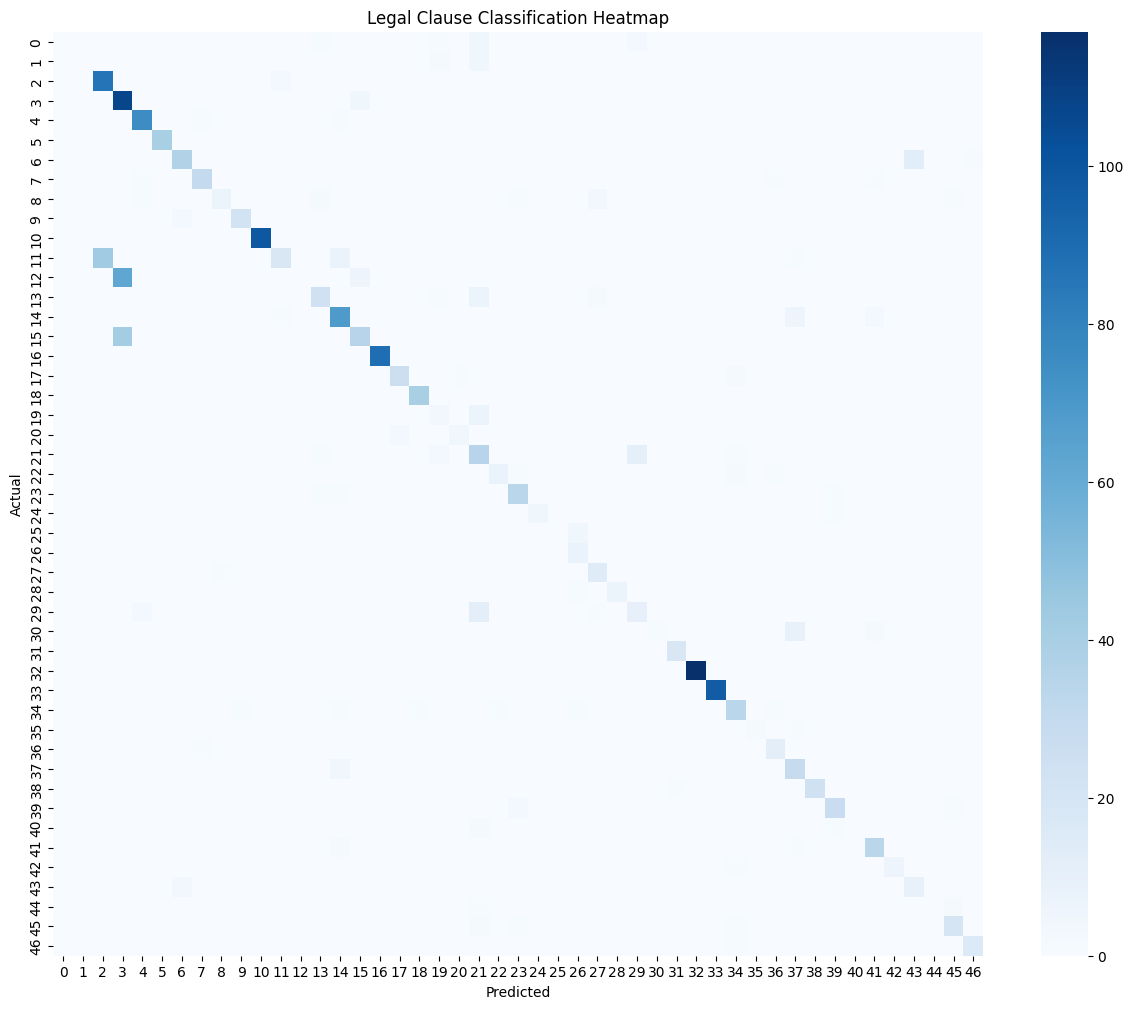

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Get predictions for the test set
predictions = trainer.predict(tokenized_test)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# 2. Create the matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=False, cmap='Blues') # 'annot=False' because 47 labels is too many for text
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Legal Clause Classification Heatmap')
plt.show()

In [ ]:
!pip install -q gradio

import gradio as gr

def legal_ai_interface(text):
    # Process the text exactly like your model expects
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to("cuda")
    with torch.no_grad():
        outputs = model(**inputs)

    # Calculate probabilities
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    confidences = {label_map[i]: float(probs[0][i]) for i in range(len(label_map))}

    # Return the top predictions
    return confidences

# Create the UI
demo = gr.Interface(
    fn=legal_ai_interface,
    inputs=gr.Textbox(lines=5, placeholder="Paste a legal clause here...", label="Input Legal Text"),
    outputs=gr.Label(num_top_classes=3, label="Predicted Clause Types"),
    title="Legal-NLU: AI Contract Analyzer",
    description="Fine-tuned Legal-BERT model to identify 47 types of legal clauses in real-time.",
    examples=["This Agreement is governed by the laws of New York.",
              "The vendor shall indemnify the client against all claims."]
)

# Launch it!
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dc51d67b68a9b8cfa4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Define the path in your Google Drive
save_path = "/content/drive/MyDrive/Legal_NLU_Final_Model"

# Create the folder if it doesn't exist
if not os.path.exists(save_path):
    os.makedirs(save_path)

# Save the model
model.save_pretrained(save_path)

# Save the tokenizer (very important for processing new text later!)
tokenizer.save_pretrained(save_path)

# Save the label map so you remember which number corresponds to which legal clause
import json
with open(f"{save_path}/label_map.json", "w") as f:
    json.dump(label_map, f)

print(f"Success! Your 80% accuracy model is now safely stored at: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Success! Your 80% accuracy model is now safely stored at: /content/drive/MyDrive/Legal_NLU_Final_Model
